# Pretrained ResNet18模型
**使用振荡器模拟出来的频率**

1. 采用**分层采样**：“每个手指固定 6 张训练、2 张测试”
能确保模型在训练时见过每一个手指，在测试时也能评估每一个手指。
2. 训练集：测试集 = 6:2，保持了合理的训练数据量，同时保证了测试的代表性。
3. **使用LR=0.001并进行学习率衰退**

**Result: 96.82%的测试准确率**

In [1]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, models
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm

from torch.utils.data import Subset
from collections import defaultdict
import random

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
device

device(type='cuda')

- 固定随机性种子

In [4]:
SEED = 42

In [5]:
def seed_everything(seed=42):
    # 1. 固定 Python 和 NumPy 的随机种子
    random.seed(seed)
    np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    
    # 2. 固定 PyTorch 的随机种子
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed) # 如果使用多张显卡
    
    # 3. 固定 cuDNN 的行为
    # torch.backends.cudnn.deterministic = True
    # torch.backends.cudnn.benchmark = False
    
    # 4. (可选) 针对特定版本的 PyTorch 强制使用确定性算法
    # 注意：某些操作可能没有确定性实现，开启后可能会报错
    # torch.use_deterministic_algorithms(True) 

    print(f"随机种子已固定为: {seed}")

# 在训练前调用
seed_everything(SEED)

随机种子已固定为: 42


In [6]:
# 创建全局的generator
g = torch.Generator()
g.manual_seed(SEED)

## 1. 读取指纹数据

- 自定义读取图片的Dataset类

In [7]:
class FVC2002Dataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        # 过滤出所有的 .tif 文件
        self.image_files = [f for f in os.listdir(root_dir) if f.endswith('.tif')]

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_name = self.image_files[idx]
        img_path = os.path.join(self.root_dir, img_name)
        
        # 加载图像并转为灰度图（指纹图通常是单通道）
        image = Image.open(img_path).convert('L')
        
        # 解析标签：例如 "10_3.tif" -> 标签为 10
        # 注意：类别索引通常从 0 开始，所以我们将 ID 减 1
        label = int(img_name.split('_')[0]) - 1
        
        if self.transform:
            image = self.transform(image)
            
        return image, label

- 自定义Transform作为振荡器模拟出来的结果

In [8]:
class FingerprintExpMapping:
    def __init__(self):
        self.a = -463.5902
        self.b = -0.0032 # 0.0008 * 4
        self.c = 551.9639

    def __call__(self, tensor):
        # 计算
        x = tensor * 255.0  # 将 [0, 1] 的像素值还原到 [0, 255]
        y = self.a * torch.exp(self.b * x) + self.c
        # 归一化到 [0, 1]
        return (y - 88.3737) / (346.9657 - 88.3737)

# # 使用方式
# transform = transforms.Compose([
#     transforms.ToTensor(),
#     FingerprintExpMapping(),
#     transforms.Normalize(...)
# ])

In [9]:
# 计算变换过后的均值和标准差
# 临时加载数据集（ToTensor + FingerprintExpMapping）
transformed_dataset = FVC2002Dataset(root_dir='../FVC2002/Db1',
                        transform=transforms.Compose([
                        transforms.Grayscale(),
                        transforms.ToTensor(),
                        FingerprintExpMapping()
                               ]))


def calculate_mean_std(dataset):
    """
    Calculates the mean and standard deviation of a PyTorch dataset.

    Args:
        dataset (torch.utils.data.Dataset): The dataset for which to
                                            calculate the stats. It should
                                            return image tensors.

    Returns:
        (torch.Tensor, torch.Tensor): A tuple containing the mean and
                                      standard deviation tensors, each of
                                      shape (C,).
    """
    # Create a DataLoader to iterate through the dataset in batches for efficiency.
    # shuffle=False because the order of images doesn't matter for this calculation.
    loader = DataLoader(dataset, batch_size=64, shuffle=False, num_workers=0, generator=g)

    # Initialize tensors to store the sum of pixel values for each (RGB) channel.
    channel_sum = torch.zeros(1)
    # Initialize tensors to store the sum of squared pixel values for each channel.
    channel_sum_sq = torch.zeros(1)
    # Initialize a counter for the total number of pixels.
    num_pixels = 0

    # Wrap the loader with tqdm to create a progress bar for monitoring.
    for images, _ in tqdm(loader, desc="Calculating Dataset Stats"):
        # Add the total number of pixels in this batch to the running total.
        num_pixels += images.size(0) * images.size(2) * images.size(3)
        
        # Sum the pixel values across the batch, height, and width dimensions,
        # leaving only the channel dimension. Add this to the running total.
        channel_sum += images.sum(dim=[0, 2, 3])
        
        # Square each pixel value, then sum them up similarly to the step above.
        channel_sum_sq += (images ** 2).sum(dim=[0, 2, 3])

    # Calculate the mean for each channel.
    mean = channel_sum / num_pixels
    # Calculate the standard deviation using the formula: sqrt(E[X^2] - E[X]^2)
    std = (channel_sum_sq / num_pixels - mean ** 2) ** 0.5

    # Return the calculated mean and standard deviation.
    return mean, std

mean, std = calculate_mean_std(transformed_dataset)
print(f"Mean: {mean}, Std: {std}")

Calculating Dataset Stats:   0%|          | 0/14 [00:00<?, ?it/s]

Mean: tensor([0.8748]), Std: tensor([0.2261])


In [10]:
class ApplyTransform(Dataset):
    """
    一个简单的装饰器类，用于给 Subset 应用特定的 transform
    """
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform
        
    def __getitem__(self, index):
        x, y = self.subset[index]
        if self.transform:
            x = self.transform(x)
        return x, y
        
    def __len__(self):
        return len(self.subset)

# 1. 定义两个不同的 Pipeline
# 基础操作（训练和测试共有）
base_ops = [
    transforms.CenterCrop(320),  # 中心裁剪到320x320
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)     # 标准差变化
]

# 训练集特有：加入随机旋转
train_transforms = transforms.Compose([
    transforms.RandomRotation(25, fill=(255,)),  # 随机旋转 ±25 度，空白处填充白色
    *base_ops
])

# 测试集：仅基础操作
test_transforms = transforms.Compose(base_ops)

# 2. 原始数据集加载时不带 transform (或者只带 Resize)
full_dataset = FVC2002Dataset(root_dir='../FVC2002/Db1', transform=None)

# --- 2. 建立标签到索引的映射 (字典结构) ---
# 这一步是为了找出每个手指对应的 8 张图分别在列表的哪个位置
label_to_indices = defaultdict(list)
for idx, img_name in enumerate(full_dataset.image_files):
    # 使用与你 Dataset 类中一致的解析逻辑
    label = int(img_name.split('_')[0]) - 1
    label_to_indices[label].append(idx)

train_indices = []
test_indices = []

# --- 3. 核心：对每一个类别固定分配 6/2 ---
# 确保每个类（手指）都参与了划分
for label, indices in label_to_indices.items():
    # 随机打乱当前手指的 8 张图索引
    random.shuffle(indices)
    
    # 取前 6 张作为训练，后 2 张作为测试
    train_indices.extend(indices[:6])
    test_indices.extend(indices[6:])

# --- 4. 创建 Subset 并应用不同的 Transform ---
# 先利用索引创建子集
train_subset = Subset(full_dataset, train_indices)
test_subset = Subset(full_dataset, test_indices)
# 5. 分别包装，应用不同的 transform
train_dataset = ApplyTransform(train_subset, transform=train_transforms)
test_dataset = ApplyTransform(test_subset, transform=test_transforms)

In [11]:
len(train_dataset), len(test_dataset)

(660, 220)

In [12]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, generator=g)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, generator=g)

## 2. 构建模型

### 2.1 ResNet 18

### 2.1.1 调用官方预训练模型

In [13]:
def get_model(num_classes=110): # FVC2002 DB1 通常是 110 类
    # 1. 加载预训练模型
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    
    # 2. 保存原始的 conv1 权重
    original_conv1 = model.conv1
    
    # 3. 创建新的单通道 conv1
    model.conv1 = nn.Conv2d(1, 64, kernel_size=3, stride=1, padding=1, bias=False)
    
    # 4. 【核心改进】将 3 通道权重合并到 1 通道，而不是随机初始化
    # 将 RGB 权重的均值赋给单通道
    with torch.no_grad():
        model.conv1.weight.data = original_conv1.weight.data.sum(dim=1, keepdim=True)
    
    # 5. 修改全连接层
    num_ftrs = model.fc.in_features
    
    # 针对小数据集，建议在 FC 层前加个 Dropout 防止过拟合
    model.fc = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(num_ftrs, num_classes)
    )
    
    return model

In [14]:
# 查看模型结构
model = get_model(num_classes=110)
print(model)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [06:29<00:00, 120kB/s] 

ResNet(
  (conv1): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

## 3. 模型训练

In [15]:
# 1. 训练一个 Epoch 的函数
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
    train_loss = running_loss / len(loader)
    train_acc = 100. * correct / total
    return train_loss, train_acc

In [16]:
# 2. 验证/测试函数 (基于你提供的 evaluate 修改)
def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
    val_loss = running_loss / len(loader)
    val_acc = 100. * correct / total
    return val_loss, val_acc

In [17]:
# 3. 总训练控制函数
def train(model, train_loader, test_loader, criterion, optimizer, device, scheduler=None, epochs=20):
    # 用于记录历史数据以便绘图
    history = {
        'train_loss': [], 'train_acc': [],
        'test_loss': [], 'test_acc': []
    }
    
    print(f"开始训练，设备: {device}")
    for epoch in range(epochs):
        # 训练阶段
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        # 验证阶段
        test_loss, test_acc = validate(model, test_loader, criterion, device)
        
        # 每个 epoch 结束更新学习率
        if scheduler is not None:
            if isinstance(scheduler, optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(test_acc)  # 以验证准确率为指标调整学习率
            else:
                scheduler.step()  # 其他类型的调度器直接调用 step()
            current_lr = optimizer.param_groups[0]['lr']

        # 记录历史
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['test_loss'].append(test_loss)
        history['test_acc'].append(test_acc)
        
        print(f"[Epoch {epoch+1}/{epochs}](LR: {current_lr:.6f}) -> "
              f"Train Acc: {train_acc:.2f}%, Test Acc: {test_acc:.2f}% | "
              f"Train Loss: {train_loss:.4f}")

    # 训练结束后进行可视化
    plot_history(history)
    return history

# 4. 可视化函数
def plot_history(history):
    epochs = range(1, len(history['train_acc']) + 1)
    
    plt.figure(figsize=(12, 5))
    
    # 绘制准确率曲线
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_acc'], 'b-', label='Training Acc')
    plt.plot(epochs, history['test_acc'], 'r-', label='Test Acc')
    plt.title('Training and Test Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    
    # 绘制损失曲线
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['train_loss'], 'b-', label='Training Loss')
    plt.plot(epochs, history['test_loss'], 'r-', label='Test Loss')
    plt.title('Training and Test Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

### 3.1 ResNet18

### 3.1.1 预训练模型

##### 余弦退火

总参数量: 11,226,670
开始训练，设备: cuda
[Epoch 1/100](LR: 0.001000) -> Train Acc: 1.21%, Test Acc: 2.73% | Train Loss: 4.9618
[Epoch 2/100](LR: 0.000999) -> Train Acc: 5.45%, Test Acc: 10.45% | Train Loss: 4.2040
[Epoch 3/100](LR: 0.000998) -> Train Acc: 17.58%, Test Acc: 17.73% | Train Loss: 3.5924
[Epoch 4/100](LR: 0.000996) -> Train Acc: 25.00%, Test Acc: 6.82% | Train Loss: 3.0636
[Epoch 5/100](LR: 0.000994) -> Train Acc: 34.39%, Test Acc: 30.45% | Train Loss: 2.6416
[Epoch 6/100](LR: 0.000991) -> Train Acc: 45.30%, Test Acc: 30.91% | Train Loss: 2.2006
[Epoch 7/100](LR: 0.000988) -> Train Acc: 54.24%, Test Acc: 52.27% | Train Loss: 1.8371
[Epoch 8/100](LR: 0.000984) -> Train Acc: 65.15%, Test Acc: 52.73% | Train Loss: 1.4804
[Epoch 9/100](LR: 0.000980) -> Train Acc: 69.24%, Test Acc: 55.45% | Train Loss: 1.2884
[Epoch 10/100](LR: 0.000976) -> Train Acc: 77.42%, Test Acc: 66.82% | Train Loss: 1.0374
[Epoch 11/100](LR: 0.000971) -> Train Acc: 81.82%, Test Acc: 65.00% | Train Loss: 0.8953
[Ep

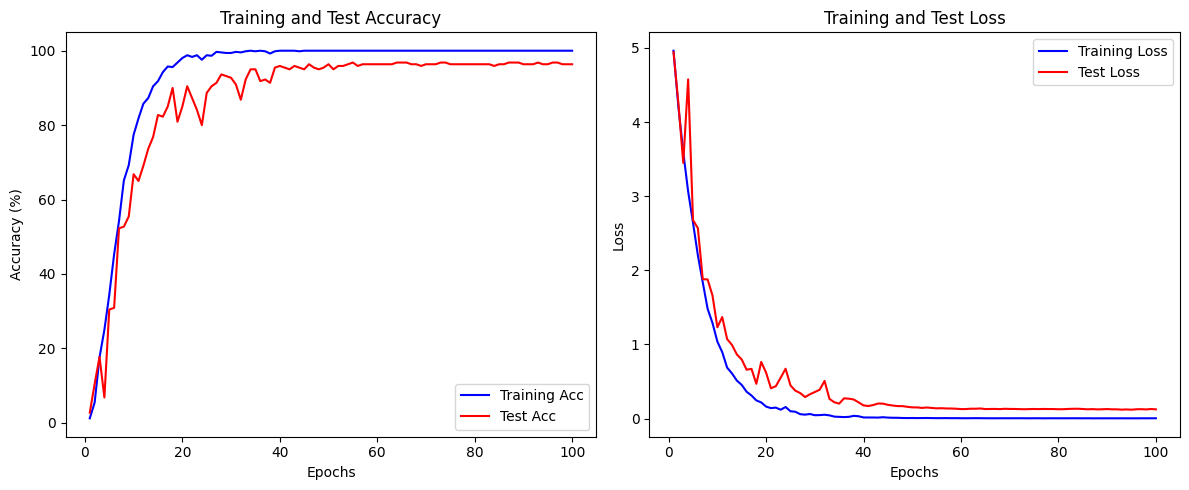

In [18]:
resnet_pretrained_1 = get_model(num_classes=110).to(device)
optimizer = optim.Adam(resnet_pretrained_1.parameters(), lr=0.001)
# 进行学习率衰退, 使用CosineAnnealingLR
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100, eta_min=1e-5)
criterion = nn.CrossEntropyLoss()
total_params = sum(p.numel() for p in resnet_pretrained_1.parameters())
print(f"总参数量: {total_params:,}")
history1 = train(resnet_pretrained_1, train_loader, test_loader, criterion, optimizer, device, scheduler, epochs=100)

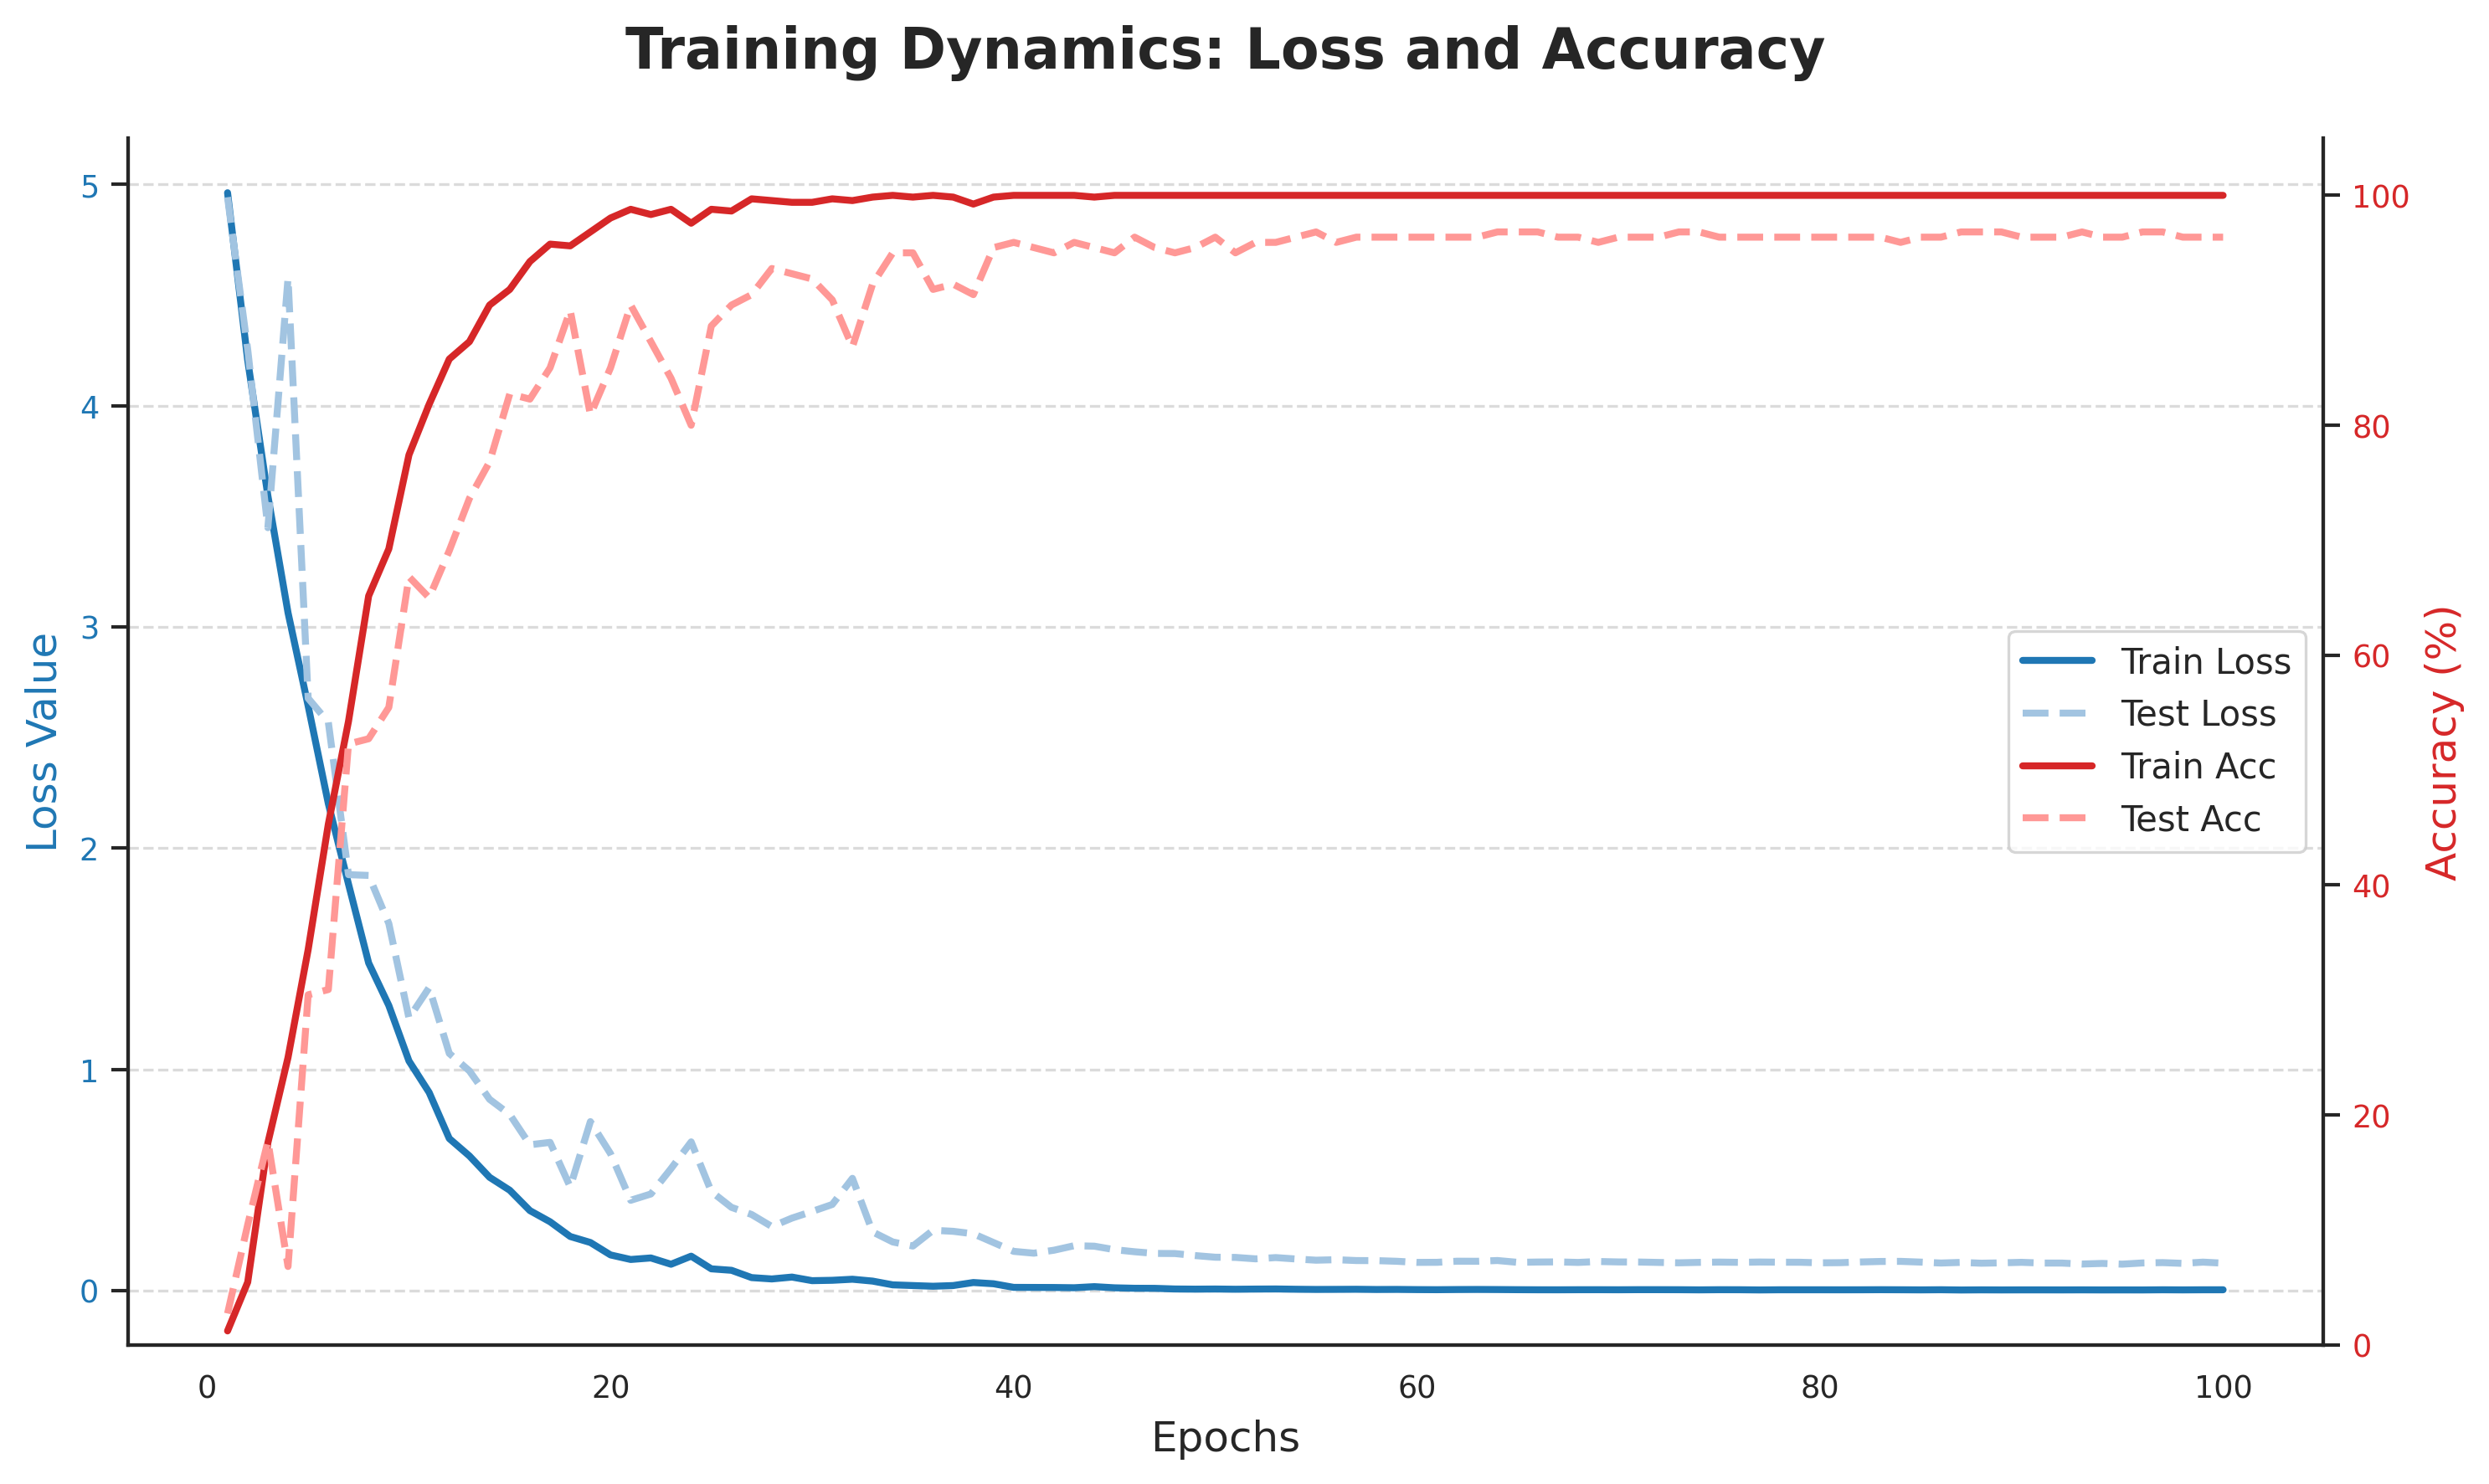

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_combined_history(history, save_name="combined_metrics.png"):
    # 1. 设置基础风格
    sns.set_theme(style="white", context="paper")
    fig, ax1 = plt.subplots(figsize=(10, 6), dpi=300)
    
    epochs = range(1, len(history['train_loss']) + 1)
    
    # --- 第一部分：绘制 Loss (左侧纵轴) ---
    color_loss_train = '#1f77b4' # 深蓝色
    color_loss_test = '#a2c4e1'  # 浅蓝色
    
    lns1 = ax1.plot(epochs, history['train_loss'], color=color_loss_train, 
                    linewidth=2, label='Train Loss')
    lns2 = ax1.plot(epochs, history['test_loss'], color=color_loss_test, 
                    linewidth=2, linestyle='--', label='Test Loss')
    
    ax1.set_xlabel('Epochs', fontsize=12)
    ax1.set_ylabel('Loss Value', fontsize=12, color=color_loss_train)
    ax1.tick_params(axis='y', labelcolor=color_loss_train)
    ax1.grid(axis='y', linestyle='--', alpha=0.7) # 只保留水平网格线

    # --- 第二部分：绘制 Accuracy (右侧纵轴) ---
    ax2 = ax1.twinx() # 创建共享 X 轴的右侧纵轴
    
    color_acc_train = '#d62728' # 深红色
    color_acc_test = '#ff9896'  # 浅红色
    
    lns3 = ax2.plot(epochs, history['train_acc'], color=color_acc_train, 
                    linewidth=2, label='Train Acc')
    lns4 = ax2.plot(epochs, history['test_acc'], color=color_acc_test, 
                    linewidth=2, linestyle='--', label='Test Acc')
    
    ax2.set_ylabel('Accuracy (%)', fontsize=12, color=color_acc_train)
    ax2.tick_params(axis='y', labelcolor=color_acc_train)
    
    # 设置右侧轴的范围 (通常准确率在 0-100 之间)
    ax2.set_ylim(0, 105) 

    # --- 第三部分：合并图例 ---
    # 因为有两个轴，需要手动合并图例标签
    lns = lns1 + lns2 + lns3 + lns4
    labs = [l.get_label() for l in lns]
    ax1.legend(lns, labs, loc='center right', frameon=True, fontsize=10)
    
    # 标题与细节
    plt.title('Training Dynamics: Loss and Accuracy', fontsize=16, fontweight='bold', pad=20)
    sns.despine(right=False) # 保持右侧轴可见
    
    plt.tight_layout()
    plt.savefig(f'../Data/Actual/{save_name}', dpi=300)
    plt.show()

# 调用函数
plot_combined_history(history1)

In [ ]:
# 将history保存为csv文件
import pandas as pd

# 1. 将 history 字典转换为 Pandas DataFrame
df = pd.DataFrame(history1)

# 2. 可选：插入 epoch 列使其更直观（从 1 开始）
df.insert(0, 'epoch', range(1, len(df) + 1))

# 3. 保存为 CSV 文件
save_path = '../Data/Actual/loss_accuracy_actual.csv'
df.to_csv(save_path, index=False)

print(f"训练历史数据已成功保存至: {save_path}")

训练历史数据已成功保存至: ../Data/loss_accuracy_actual.csv


In [23]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   epoch       100 non-null    int64  
 1   train_loss  100 non-null    float64
 2   train_acc   100 non-null    float64
 3   test_loss   100 non-null    float64
 4   test_acc    100 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 4.0 KB


#### 绘制混淆矩阵

In [30]:
def get_all_preds_and_labels(model, loader, device):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            
            # 将数据转回 CPU 并存储为 numpy 数组
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    return np.array(all_labels), np.array(all_preds)

from sklearn.metrics import confusion_matrix
import seaborn as sns

def plot_cm(y_true, y_pred, num_classes):
    # 计算混淆矩阵
    cm = confusion_matrix(y_true, y_pred)
    
    # 设置画布大小 (因为你有110类，建议设大一点)
    plt.figure(figsize=(20, 18))
    
    # 绘制热力图
    # annot=False: 110个类如果显示数字会糊成一团，所以关掉数字显示
    # cmap="Blues": 使用蓝色调
    sns.heatmap(cm, annot=False, fmt='d', cmap='Blues', 
                xticklabels=False, yticklabels=False) # 隐藏坐标轴标签防止重叠
    
    plt.title(f'Confusion Matrix for {num_classes} Fingerprint Classes')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    # 保存图片
    plt.savefig(f'../Data/Actual/confusion_matrix_{num_classes}_classes.png', dpi=300) # 保存高质量图片用于论文"

    plt.show()

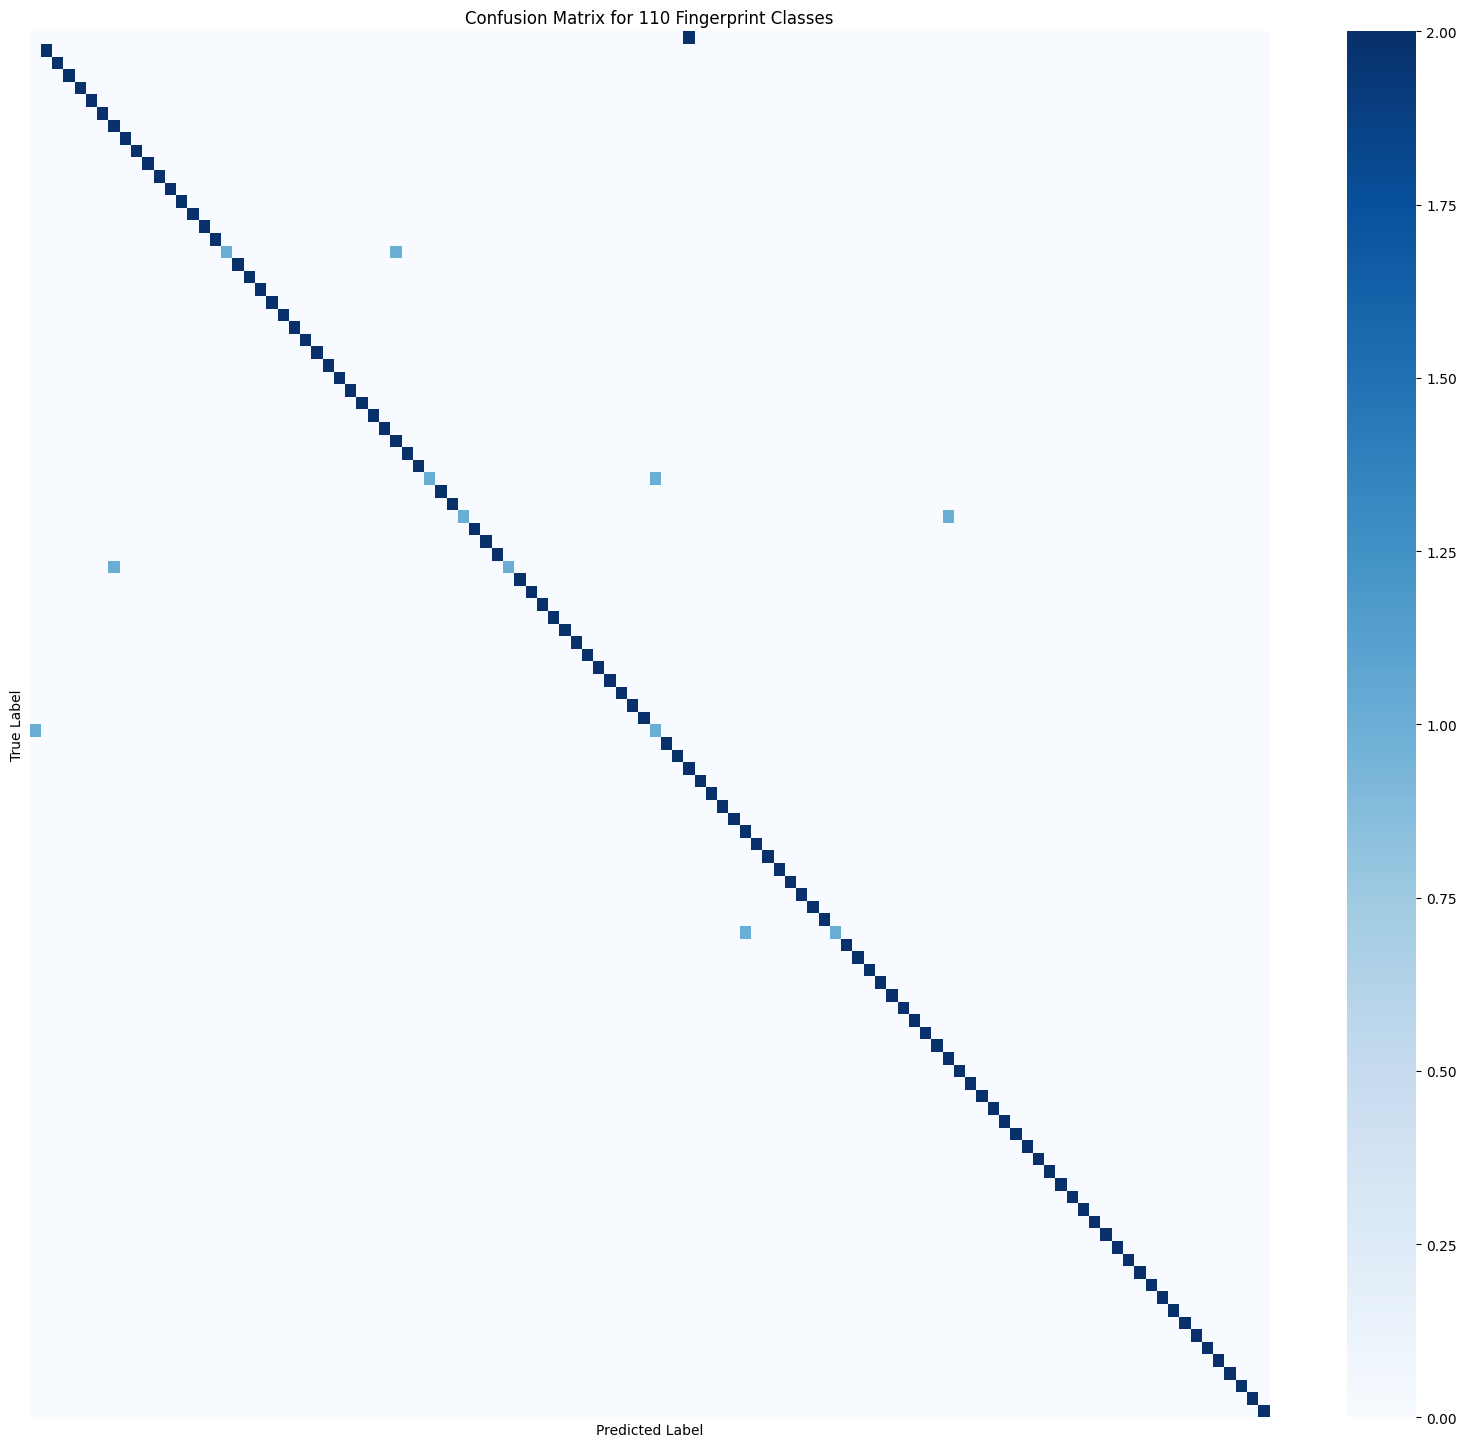

In [31]:
# 1. 获取所有预测结果
y_true, y_pred = get_all_preds_and_labels(resnet_pretrained_1, test_loader, device)

# 2. 绘制并显示
plot_cm(y_true, y_pred, num_classes=110)

In [34]:
# 保存混淆矩阵数据为 CSV 文件
def save_cm_to_csv(y_true, y_pred, num_classes, filename="confusion_matrix_data.csv"):
    """
    计算混淆矩阵并保存为带有行列标签的 CSV 文件
    """
    # 1. 计算混淆矩阵 (110x110)
    cm = confusion_matrix(y_true, y_pred)
    
    # 2. 创建行列标签，方便在 Excel 中查看
    # True_0, True_1... 代表真实类别；Pred_0, Pred_1... 代表预测类别
    columns = [f'Pred_{i}' for i in range(num_classes)]
    index = [f'True_{i}' for i in range(num_classes)]
    
    # 3. 转换为 DataFrame
    df_cm = pd.DataFrame(cm, index=index, columns=columns)
    
    # 4. 保存文件
    df_cm.to_csv(f'../Data/Actual/{filename}', index=True)
    print(f"混淆矩阵数据已成功保存至: {filename}")

# --- 使用方法 ---
# 假设你已经通过之前的函数得到了 y_true 和 y_pred
# y_true, y_pred = get_all_preds_and_labels(resnet_pretrained_2, test_loader, device)

# 保存数据
save_cm_to_csv(y_true, y_pred, num_classes=110)

混淆矩阵数据已成功保存至: confusion_matrix_data.csv
